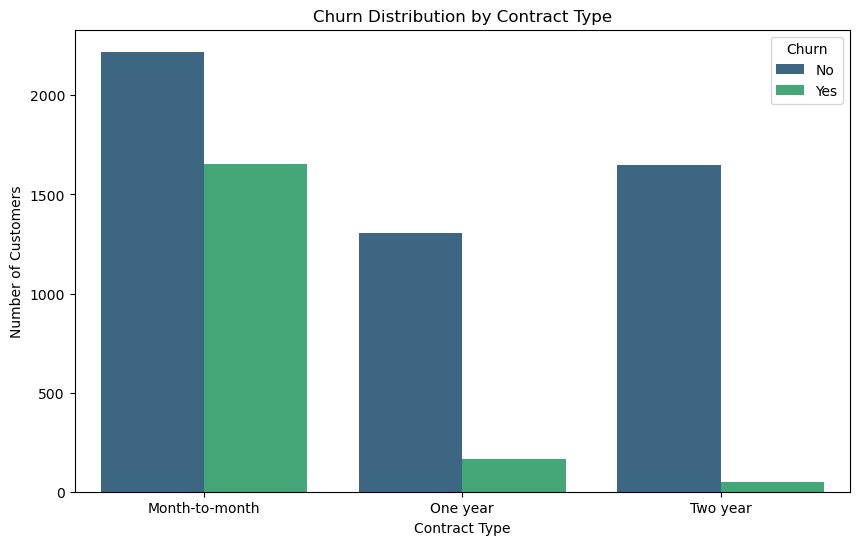

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('Telco-Customer-Churn - Telco-Customer-Churn.csv.csv')

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')

# Add titles and labels
plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

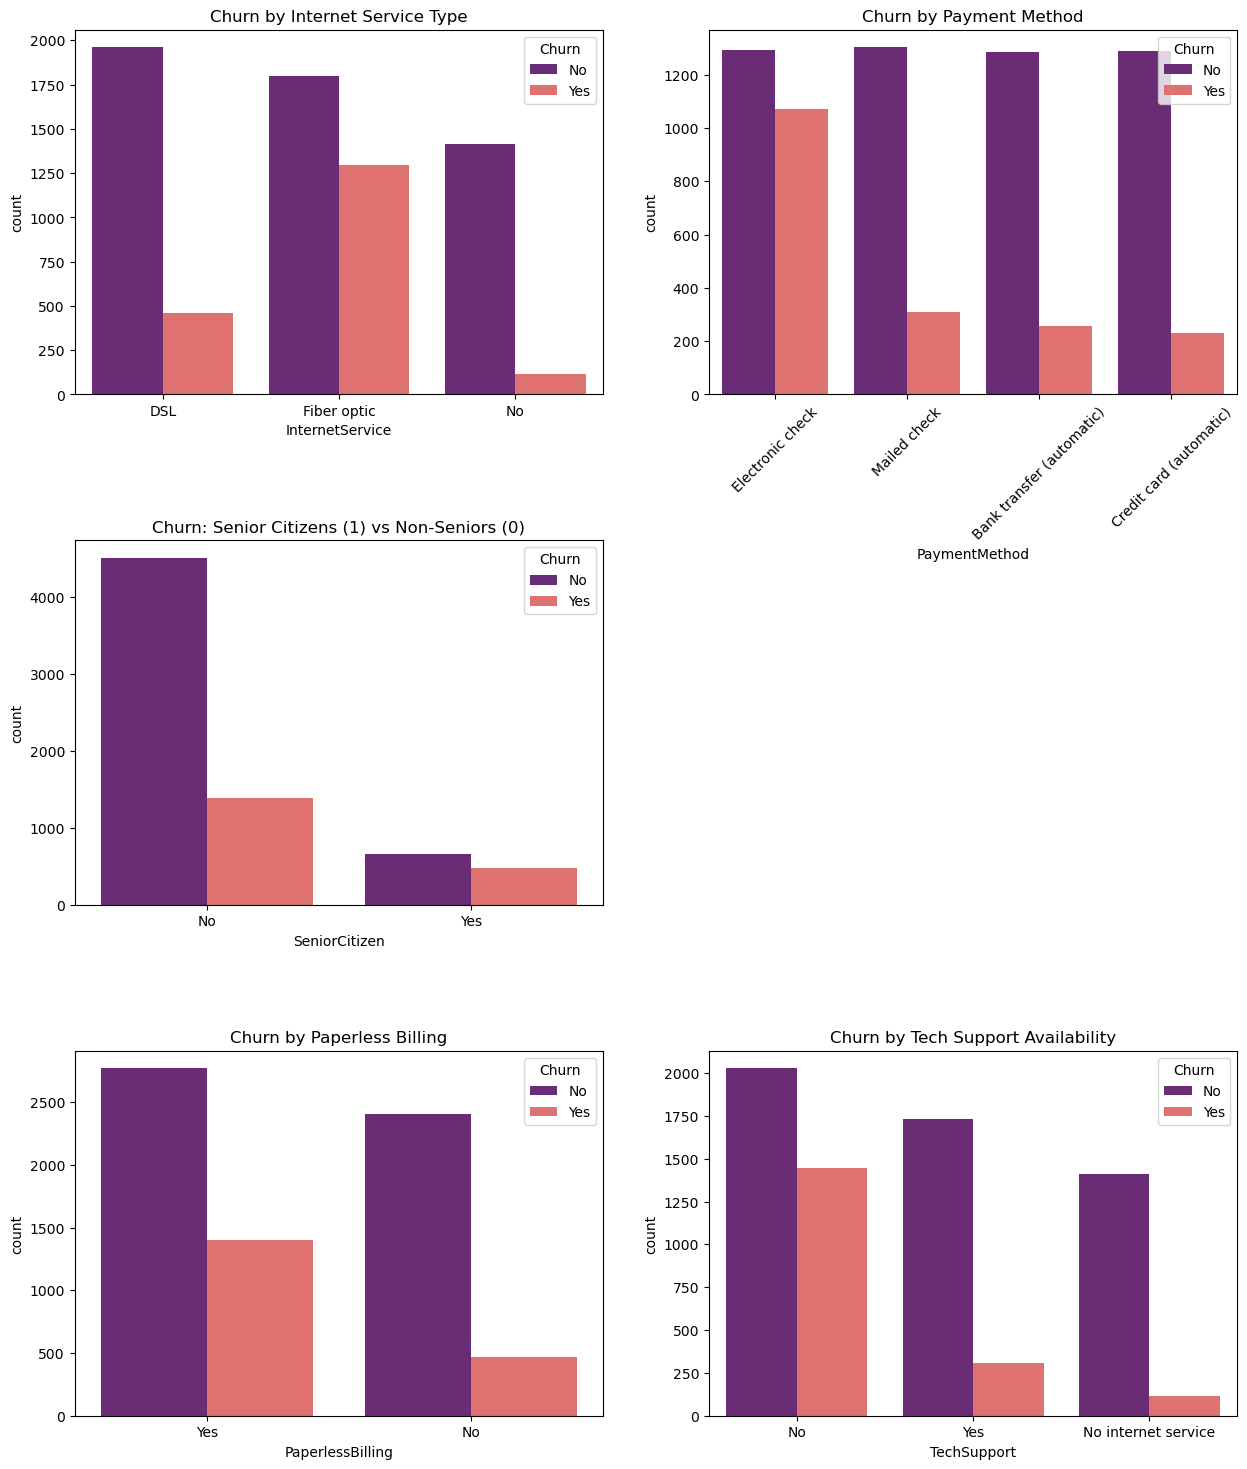

In [2]:
#Set up the figure size for 6 plots (3 rows, 2 columns)
plt.figure(figsize=(15, 18))
plt.subplots_adjust(hspace=0.4) # Add space between rows

# --- Graph 1: Churn vs Internet Service ---
plt.subplot(3, 2, 1)
sns.countplot(data=df, x='InternetService', hue='Churn', palette='magma')
plt.title('Churn by Internet Service Type')

# --- Graph 2: Churn vs Payment Method ---
plt.subplot(3, 2, 2)
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='magma')
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.title('Churn by Payment Method')

# --- Graph 3: Churn vs Senior Citizen ---
plt.subplot(3, 2, 3)
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='magma')
plt.title('Churn: Senior Citizens (1) vs Non-Seniors (0)')

# --- Graph 4: Churn vs Paperless Billing ---
plt.subplot(3, 2, 5)
sns.countplot(data=df, x='PaperlessBilling', hue='Churn', palette='magma')
plt.title('Churn by Paperless Billing')

# --- Graph 5: Churn vs Tech Support ---
plt.subplot(3, 2, 6)
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='magma')
plt.title('Churn by Tech Support Availability')

plt.show()


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load your CSV — update path if needed
df = pd.read_csv('Telco-Customer-Churn - Telco-Customer-Churn.csv.csv')

# Fix currency columns
df['MonthlyCharges'] = df['MonthlyCharges'].str.replace('[$,]', '', regex=True).astype(float)
df['TotalCharges']   = df['TotalCharges'].str.replace('[$,]', '', regex=True)
df['TotalCharges']   = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']   = df['TotalCharges'].fillna(df['MonthlyCharges'])

# Binary target
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Churn rate: {df['Churn_Binary'].mean():.1%}")
print(f"Missing values: {df.isnull().sum().sum()}")

Rows: 7043
Columns: 22
Churn rate: 26.5%
Missing values: 0


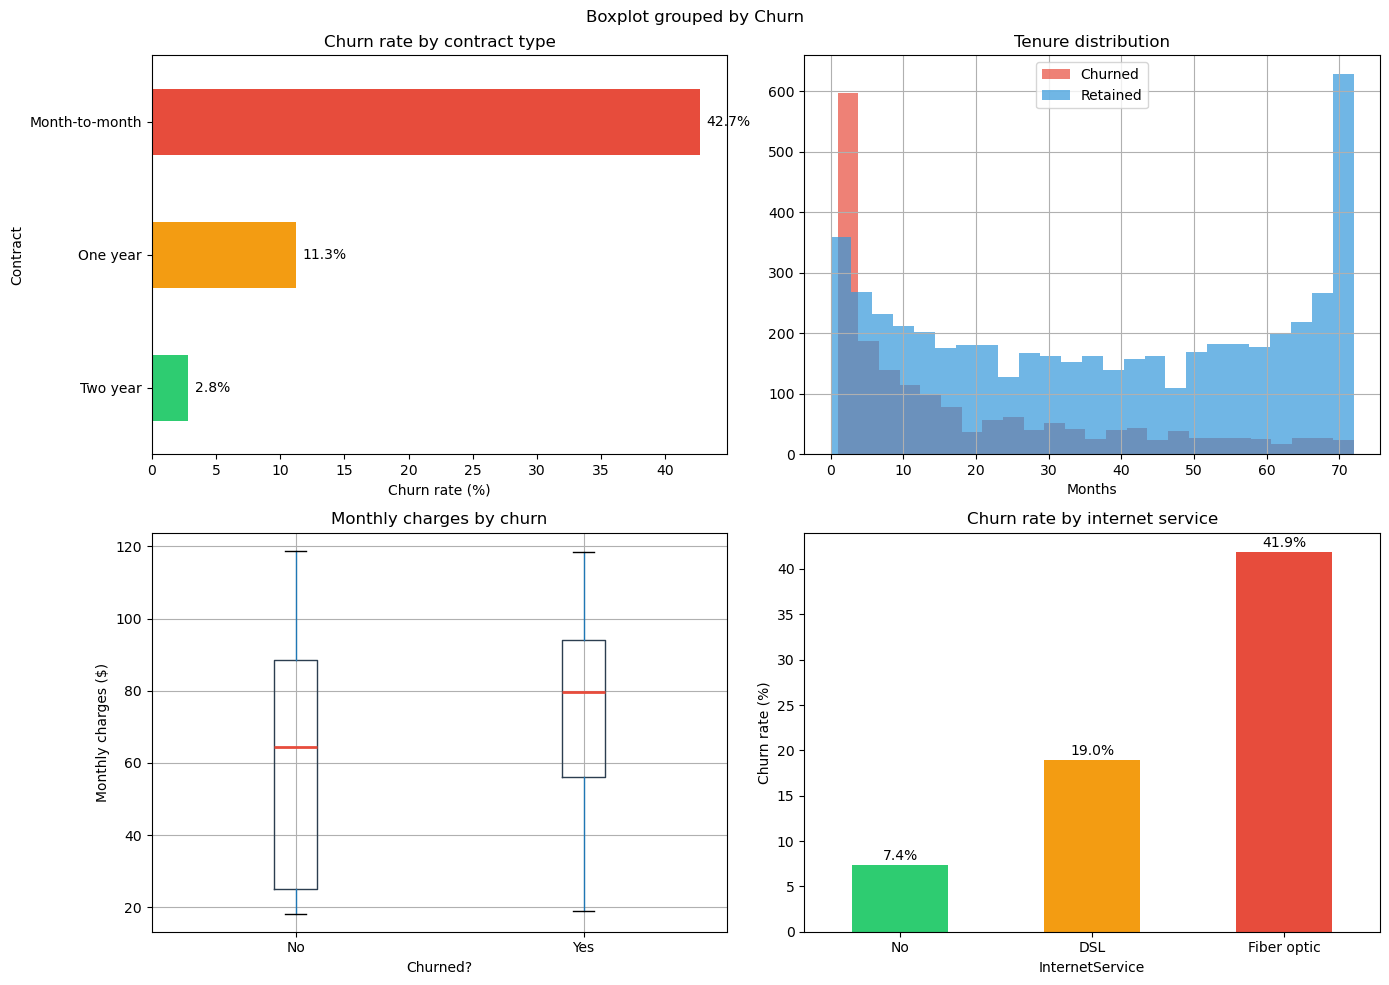

Saved: eda_plots.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn — Exploratory Analysis', fontsize=15, fontweight='bold', y=1.01)

# Chart 1 — Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values() * 100
colors = ['#2ecc71', '#f39c12', '#e74c3c']
contract_churn.plot(kind='barh', ax=axes[0,0], color=colors)
axes[0,0].set_title('Churn rate by contract type')
axes[0,0].set_xlabel('Churn rate (%)')
for i, v in enumerate(contract_churn):
    axes[0,0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

# Chart 2 — Tenure distribution
df[df['Churn']=='Yes']['tenure_in_months'].hist(
    ax=axes[0,1], bins=25, color='#e74c3c', alpha=0.7, label='Churned')
df[df['Churn']=='No']['tenure_in_months'].hist(
    ax=axes[0,1], bins=25, color='#3498db', alpha=0.7, label='Retained')
axes[0,1].set_title('Tenure distribution')
axes[0,1].set_xlabel('Months')
axes[0,1].legend()

# Chart 3 — Monthly charges boxplot
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1,0],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='#e74c3c', linewidth=2))
axes[1,0].set_title('Monthly charges by churn')
axes[1,0].set_xlabel('Churned?')
axes[1,0].set_ylabel('Monthly charges ($)')
plt.sca(axes[1,0])
plt.title('Monthly charges by churn')

# Chart 4 — Churn rate by internet service
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean().sort_values() * 100
internet_churn.plot(kind='bar', ax=axes[1,1], color=['#2ecc71','#f39c12','#e74c3c'], rot=0)
axes[1,1].set_title('Churn rate by internet service')
axes[1,1].set_ylabel('Churn rate (%)')
for i, v in enumerate(internet_churn):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_plots.png")

In [8]:
# Prepare features
df_model = df.drop(['customerID', 'Churn'], axis=1).copy()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop('Churn_Binary', axis=1)
y = df_model['Churn_Binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

# Print results
print("\n--- Model Performance ---")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.3f}")

Training rows : 5634
Testing rows  : 1409

--- Model Performance ---
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.86      1035
     Churned       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.821


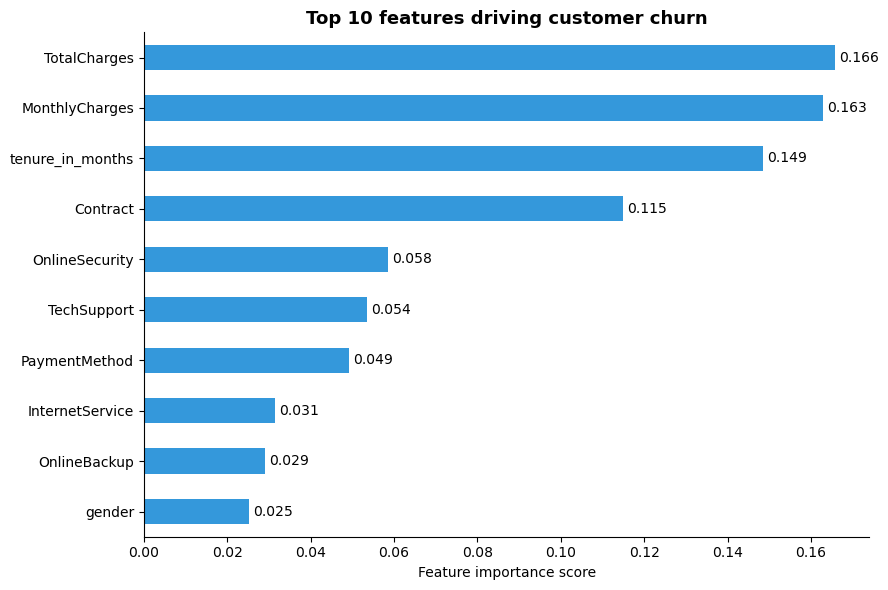


Top 10 churn drivers:
  TotalCharges               0.1657
  MonthlyCharges             0.1629
  tenure_in_months           0.1486
  Contract                   0.1150
  OnlineSecurity             0.0585
  TechSupport                0.0536
  PaymentMethod              0.0492
  InternetService            0.0314
  OnlineBackup               0.0291
  gender                     0.0252


In [9]:
# Feature importance chart
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 6))
top10.plot(kind='barh', ax=ax, color='#3498db')

for i, v in enumerate(top10):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

ax.set_title('Top 10 features driving customer churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature importance score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Ranked list
print("\nTop 10 churn drivers:")
for feat, score in importances.sort_values(ascending=False).head(10).items():
    print(f"  {feat:25s}  {score:.4f}")

In [10]:
# Adding predictions to original dataframe
df_export = df.copy()

X_full = df_model.drop('Churn_Binary', axis=1)
df_export['Churn_Probability'] = rf.predict_proba(X_full)[:, 1].round(3)
df_export['Churn_Prediction']  = rf.predict(X_full)
df_export['Risk_Segment'] = pd.cut(
    df_export['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

# Save
df_export.to_csv('telco_churn_with_predictions.csv', index=False)

print(f"Exported {len(df_export)} rows")
print("\nRisk segment breakdown:")
print(df_export['Risk_Segment'].value_counts())
print("\nSample:")
print(df_export[['customerID', 'MonthlyCharges', 'Contract',
                  'Churn', 'Churn_Probability', 'Risk_Segment']].head(5).to_string())

Exported 7043 rows

Risk segment breakdown:
Risk_Segment
Low risk       3831
High risk      1676
Medium risk     406
Name: count, dtype: int64

Sample:
   customerID  MonthlyCharges        Contract Churn  Churn_Probability Risk_Segment
0  7590-VHVEG           29.85  Month-to-month    No               0.23     Low risk
1  5575-GNVDE           56.95        One year    No               0.00          NaN
2  3668-QPYBK           53.85  Month-to-month   Yes               0.88    High risk
3  7795-CFOCW           42.30        One year    No               0.00          NaN
4  9237-HQITU           70.70  Month-to-month   Yes               0.77    High risk


In [13]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure_in_months,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,0
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,0
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,0


In [15]:
df.describe()

,tenure_in_months,MonthlyCharges,TotalCharges,Churn_Binary
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992,0.265370
std,24.559481,30.090047,2266.730170,0.441561
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000
max,72.000000,118.750000,8684.800000,1.000000
